* Import Liberaries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
import joblib

from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# file_path = '/content/drive/MyDrive/vehicle_price_prediction.csv'

# df = pd.read_csv(file_path)

# df.head()

* Read Dataset

In [3]:
FILE_PATH = os.path.join(os.getcwd(), '..' ,'dataset' ,'vehicle_price_prediction.csv')
df = pd.read_csv(FILE_PATH)

In [4]:
df.head()

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,NaN,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,NaN,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,NaN,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30


In [5]:
# Adjust Column Names
df.columns = df.columns.str.strip().str.replace(' ', '_')

In [6]:
# Estimate Engine Capacity From HP
df['engine_capacity'] = (((df['engine_hp'] * 100) / 15).round()) / 1000

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 21 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   make              1000000 non-null  object 
 1   model             1000000 non-null  object 
 2   year              1000000 non-null  int64  
 3   mileage           1000000 non-null  int64  
 4   engine_hp         1000000 non-null  int64  
 5   transmission      1000000 non-null  object 
 6   fuel_type         1000000 non-null  object 
 7   drivetrain        1000000 non-null  object 
 8   body_type         1000000 non-null  object 
 9   exterior_color    1000000 non-null  object 
 10  interior_color    1000000 non-null  object 
 11  owner_count       1000000 non-null  int64  
 12  accident_history  249867 non-null   object 
 13  seller_type       1000000 non-null  object 
 14  condition         1000000 non-null  object 
 15  trim              1000000 non-null  object 
 16  v

* Describe Statistical info

In [8]:
# Numerical Cols
df.describe()

,year,mileage,engine_hp,owner_count,vehicle_age,mileage_per_year,brand_popularity,price,engine_capacity
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2017.453816,112660.126464,235.664301,3.477846,7.585987,14540.674200,0.040001,20329.302593,1.571095
std,3.902285,72088.236925,93.614773,1.544856,3.829534,6108.901522,0.000234,13644.467189,0.624098
min,2000.000000,500.000000,90.000000,1.000000,1.000000,33.333333,0.039318,1500.000000,0.600000
25%,2015.000000,57654.000000,162.000000,2.000000,5.000000,10487.633523,0.039842,10324.527500,1.080000
50%,2018.000000,103331.000000,215.000000,4.000000,7.000000,14688.118056,0.040022,17864.740000,1.433000
75%,2020.000000,157865.000000,300.000000,5.000000,10.000000,18685.942308,0.040148,27601.402500,2.000000
max,2025.000000,300000.000000,581.000000,5.000000,25.000000,55391.000000,0.040484,93422.090000,3.873000


In [9]:
# Categorical Cols
df.describe(include='object')

,make,model,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,accident_history,seller_type,condition,trim
count,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,249867,1000000,1000000,1000000
unique,25,105,2,3,3,7,6,4,2,2,3,6
top,Kia,300,Automatic,Electric,AWD,SUV,White,Beige,Minor,Dealer,Good,Limited
freq,40484,20202,500263,359597,361110,406693,166934,250570,199981,699710,499683,167294


In [10]:
df.nunique()

make                    25
model                  105
year                    26
mileage             257043
engine_hp              478
transmission             2
fuel_type                3
drivetrain               3
body_type                7
exterior_color           6
interior_color           4
owner_count              5
accident_history         2
seller_type              2
condition                3
trim                     6
vehicle_age             25
mileage_per_year    522677
brand_popularity        24
price               850936
engine_capacity        478
dtype: int64

* Check Features importance To Target

--- Pearson Feature Importance ---
price               1.000000
year                0.664730
engine_hp           0.653339
engine_capacity     0.653339
brand_popularity    0.055940
mileage_per_year   -0.216451
owner_count        -0.449437
mileage            -0.618349
vehicle_age        -0.662811
Name: price, dtype: float64

--- Spearman Feature Importance ---
price               1.000000
year                0.695420
engine_hp           0.621049
engine_capacity     0.621049
brand_popularity   -0.031724
mileage_per_year   -0.227870
owner_count        -0.454472
mileage            -0.662143
vehicle_age        -0.695460
Name: price, dtype: float64

--- Kendall Feature Importance ---
price               1.000000
year                0.519902
engine_capacity     0.436884
engine_hp           0.436884
brand_popularity   -0.019673
mileage_per_year   -0.155725
owner_count        -0.343908
mileage            -0.478240
vehicle_age        -0.520455
Name: price, dtype: float64


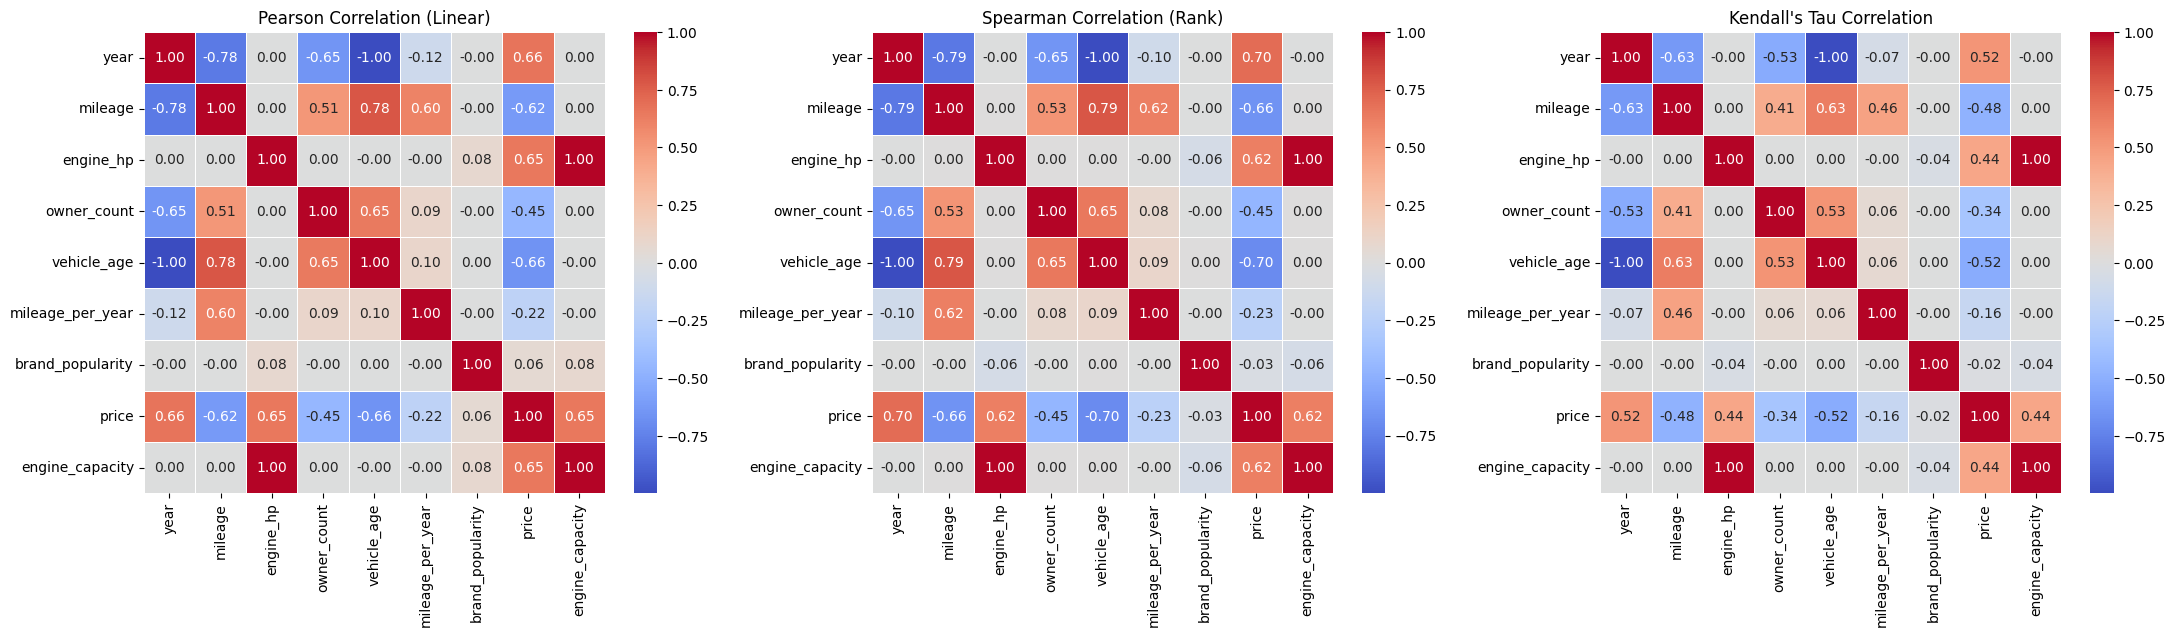

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter only numeric columns
numeric_df = df.select_dtypes(include=['int', 'float'])

# 2. Calculate Correlation matrices for all three methods
pearson_corr = numeric_df.corr(method='pearson')    # Linear relationships
spearman_corr = numeric_df.corr(method='spearman')  # Monotonic relationships (Rank-based)
kendall_corr = numeric_df.corr(method='kendall')    # Ordinal relationships (Tau-based)

target_col = 'price'

print("--- Pearson Feature Importance ---")
print(pearson_corr[target_col].sort_values(ascending=False))

print("\n--- Spearman Feature Importance ---")
print(spearman_corr[target_col].sort_values(ascending=False))

print("\n--- Kendall Feature Importance ---")
print(kendall_corr[target_col].sort_values(ascending=False))

# 4. Plot Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot Pearson Heatmap
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=axes[0])
axes[0].set_title('Pearson Correlation (Linear)')

# Plot Spearman Heatmap
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=axes[1])
axes[1].set_title('Spearman Correlation (Rank)')

# Plot Kendall Heatmap
sns.heatmap(kendall_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True, ax=axes[2])
axes[2].set_title("Kendall's Tau Correlation")

plt.tight_layout()
plt.show()

In [12]:
# P_Val  (ANOVA)
categ_cols =  np.array(df.select_dtypes('object').columns.to_list())
for col in categ_cols:
    groups = [group["price"].values for name, group in df.groupby(col)]

    f_stat, p_val = stats.f_oneway(*groups)
    print(f"Column: {col} -> p-value: {p_val}")

Column: make -> p-value: 0.0
Column: model -> p-value: 0.0
Column: transmission -> p-value: 0.16487805792395777
Column: fuel_type -> p-value: 0.0
Column: drivetrain -> p-value: 1.0911887490141171e-191
Column: body_type -> p-value: 0.0
Column: exterior_color -> p-value: 0.7241544480911836
Column: interior_color -> p-value: 0.0064558132046415835
Column: accident_history -> p-value: 0.0
Column: seller_type -> p-value: 1.0183329381318386e-245
Column: condition -> p-value: 0.0
Column: trim -> p-value: 0.264875046922677


* As Requirement Of Our Usecase : We Will Drop {'vehicle_age', 'engine_hp', 'owner_count', 'vehicle_age', 'mileage_per_year', 'brand_popularity'} (Numerical)

* {'interior_color', 'condition', 'seller_type'} (Categ)

In [13]:
df.drop(columns=['vehicle_age', 'engine_hp', 'owner_count', 'mileage_per_year', 'brand_popularity',
                  'interior_color', 'condition', 'seller_type', 'exterior_color', 'accident_history'], axis=1, inplace=True)

In [14]:
df.columns

Index(['make', 'model', 'year', 'mileage', 'transmission', 'fuel_type',
       'drivetrain', 'body_type', 'trim', 'price', 'engine_capacity'],
      dtype='object')

* Deal With Nans & Duplicates

In [15]:
df.isna().sum(axis=0)

make               0
model              0
year               0
mileage            0
transmission       0
fuel_type          0
drivetrain         0
body_type          0
trim               0
price              0
engine_capacity    0
dtype: int64

In [16]:
df[df.duplicated()] ## No Duplicates

,make,model,year,mileage,transmission,fuel_type,drivetrain,body_type,trim,price,engine_capacity
369289,Subaru,Forester,2011,300000,Automatic,Diesel,AWD,Sedan,EX,1500.0,1.113
832181,Subaru,Impreza,2010,300000,Automatic,Gasoline,AWD,Sedan,Limited,1500.0,1.107


* EDA

---

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'mileage'}>],
       [<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'engine_capacity'}>]], dtype=object)

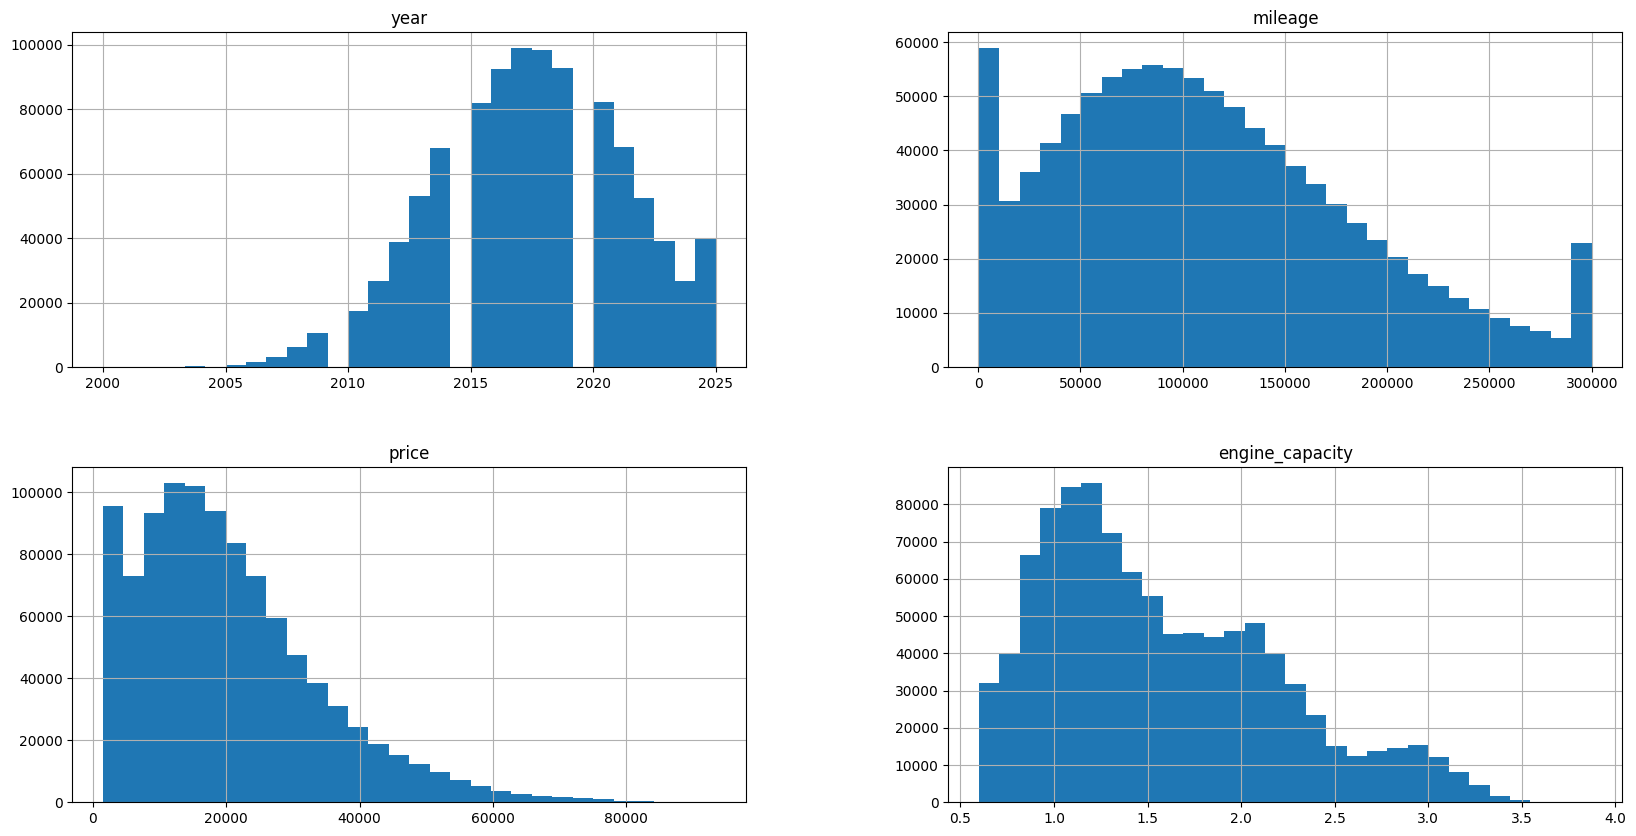

In [17]:
# Numerical Cols (Histograms)
df.hist(bins=30, figsize=(20,10))

* -- Uni Variate

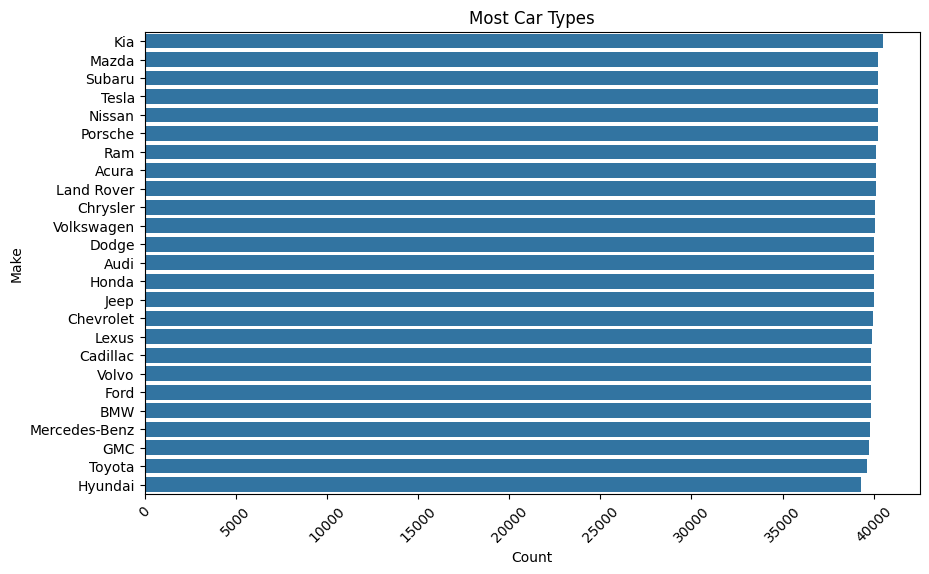

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='make', order=df['make'].value_counts().index.to_list())
plt.title("Most Car Types")
plt.xlabel("Count")
plt.ylabel("Make")
plt.xticks(rotation=45)
plt.show()

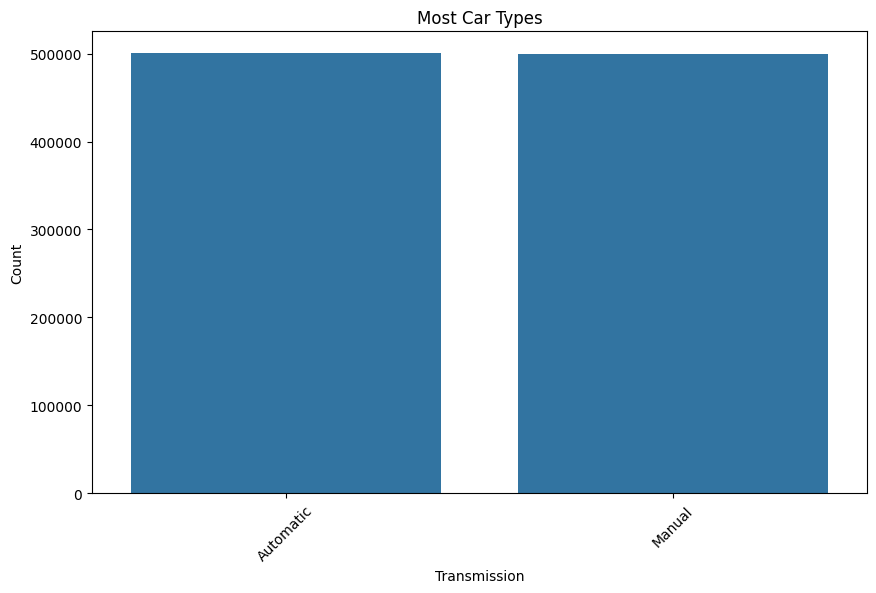

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='transmission', order=df['transmission'].value_counts().index.to_list())
plt.title("Most Car Types")
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

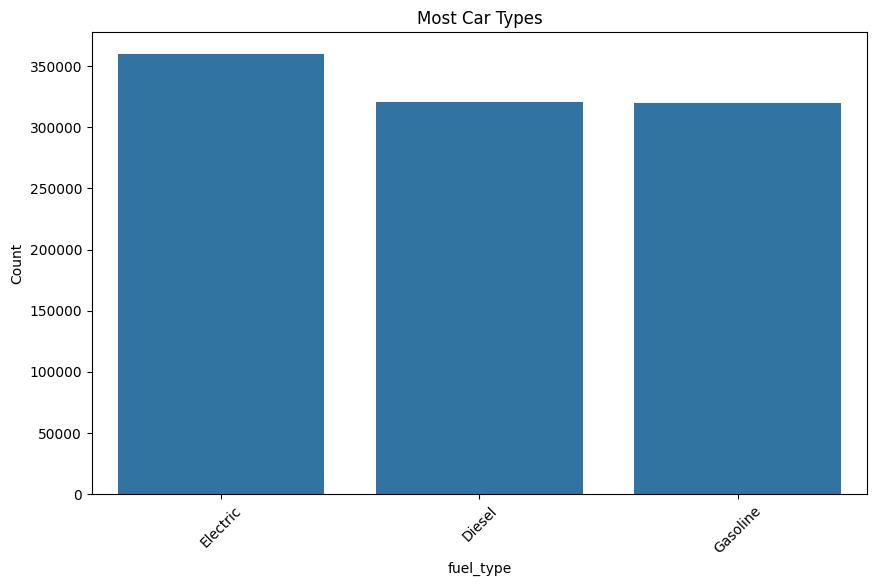

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='fuel_type', order=df['fuel_type'].value_counts().index.to_list())
plt.title("Most Car Types")
plt.xlabel("fuel_type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

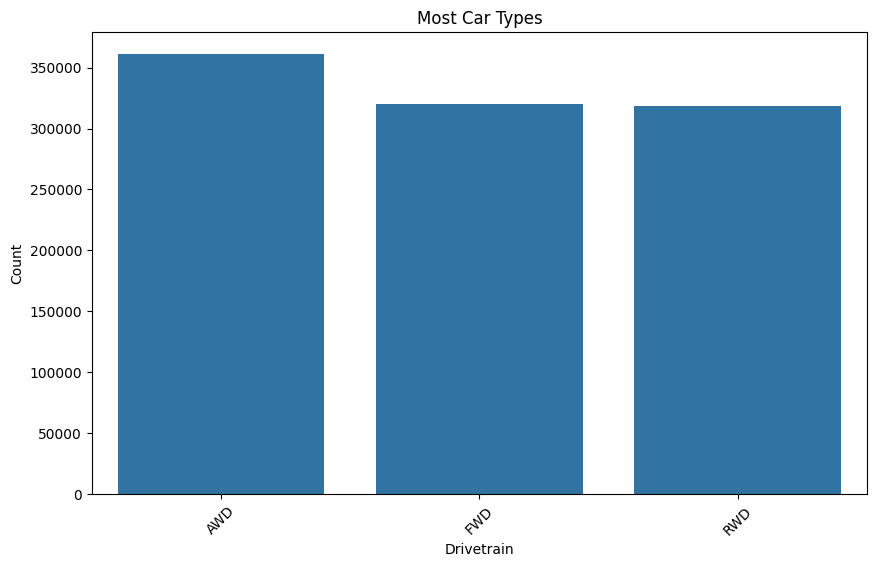

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='drivetrain', order=df['drivetrain'].value_counts().index.to_list())
plt.title("Most Car Types")
plt.xlabel("Drivetrain")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

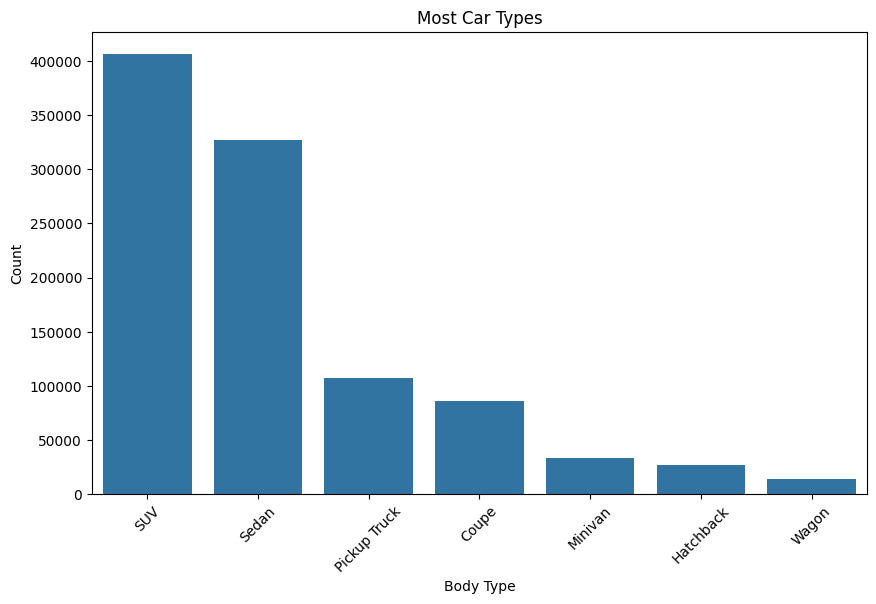

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='body_type', order=df['body_type'].value_counts().index.to_list())
plt.title("Most Car Types")
plt.xlabel("Body Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

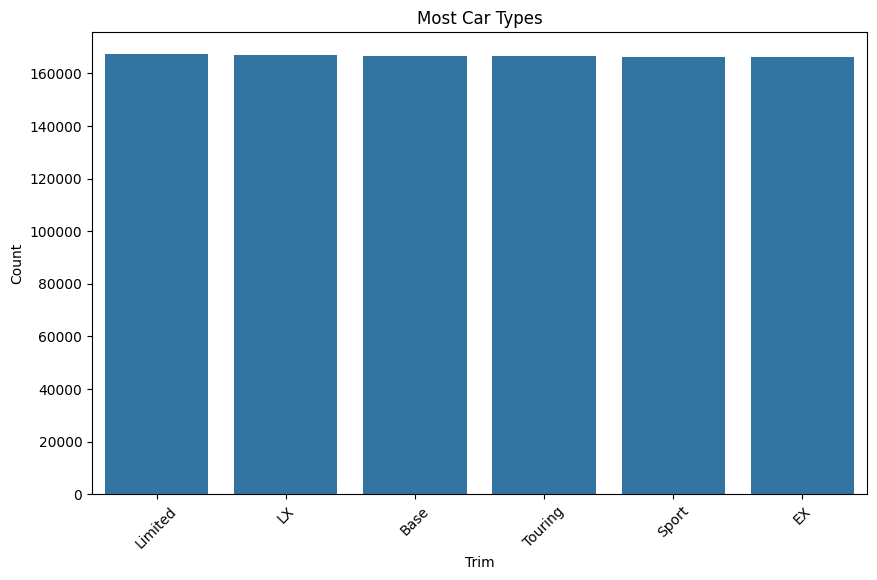

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='trim', order=df['trim'].value_counts().index.to_list())
plt.title("Most Car Types")
plt.xlabel("Trim")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

- Filter Price

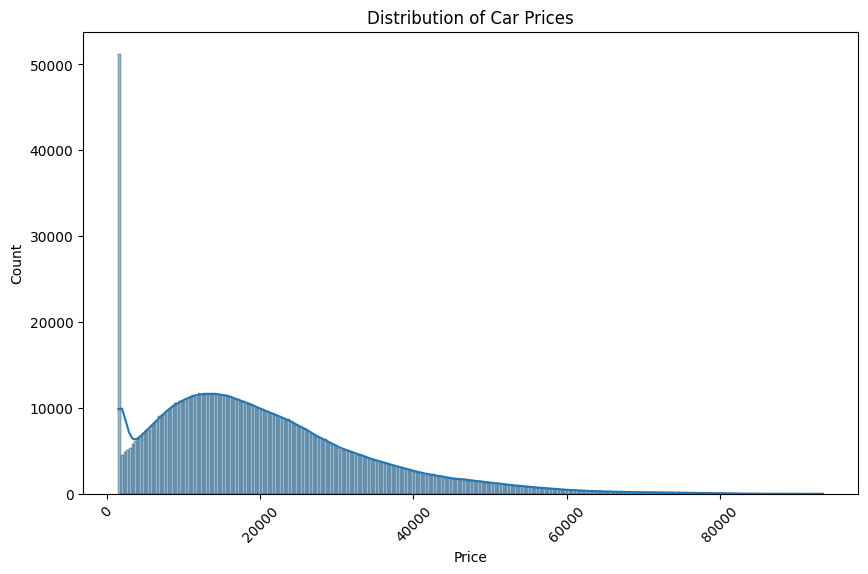

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='price', kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [25]:
df[df['price'] <= df['price'].min() + 100]['price'].value_counts()

price
1500.00    46984
1523.12        3
1545.10        3
1594.76        3
1548.03        3
           ...  
1547.17        1
1580.85        1
1593.08        1
1578.91        1
1562.38        1
Name: count, Length: 1130, dtype: int64

In [26]:
df.query("price==1500")

,make,model,year,mileage,transmission,fuel_type,drivetrain,body_type,trim,price,engine_capacity
30,Ford,Explorer,2013,234866,Manual,Gasoline,AWD,Coupe,Touring,1500.0,0.913
47,Subaru,Crosstrek,2012,256509,Automatic,Diesel,AWD,SUV,Touring,1500.0,1.087
59,Volkswagen,Tiguan,2010,189574,Manual,Electric,AWD,Hatchback,Touring,1500.0,1.087
60,Hyundai,Tucson,2010,173846,Automatic,Diesel,AWD,SUV,Sport,1500.0,1.040
106,Dodge,Challenger,2008,240744,Manual,Gasoline,AWD,Sedan,Base,1500.0,1.180
...,...,...,...,...,...,...,...,...,...,...,...
999956,Jeep,Cherokee,2011,271620,Manual,Electric,FWD,SUV,Base,1500.0,1.293
999974,Audi,Q5,2005,300000,Automatic,Electric,AWD,Coupe,LX,1500.0,2.093
999982,Nissan,Titan,2013,212337,Manual,Gasoline,FWD,SUV,EX,1500.0,0.727
999988,Nissan,Sentra,2013,226938,Automatic,Gasoline,AWD,Pickup Truck,EX,1500.0,0.947


In [27]:
df[df['price'] == 1500.00].describe(include='object')

,make,model,transmission,fuel_type,drivetrain,body_type,trim
count,46984,46984,46984,46984,46984,46984,46984
unique,24,100,2,3,3,7,6
top,Hyundai,Sonata,Automatic,Gasoline,AWD,SUV,LX
freq,5363,1402,23616,15728,17711,18235,7951


Before: (1000000, 11)
After: (953016, 11)


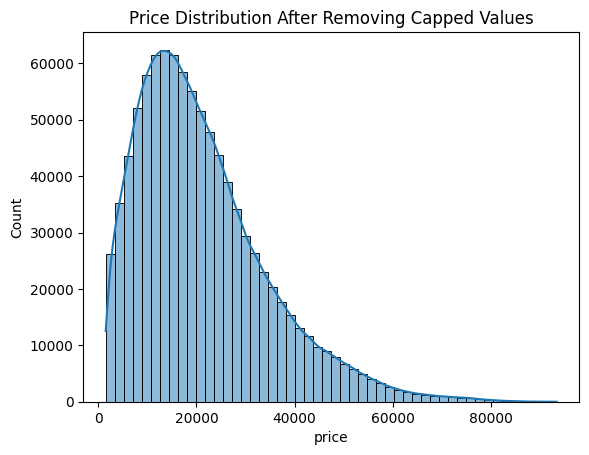

In [28]:
## Price Distribution After Removing Capped Values (Noise)

print(f"Before: {df.shape}")
df = df[df['price'] != 1500.00].copy()
print(f"After: {df.shape}")

sns.histplot(df['price'], kde=True, bins=50)
plt.title('Price Distribution After Removing Capped Values')
plt.show()

In [29]:
## Log Transform Of Price

df['price_log'] = np.log1p(df['price'])

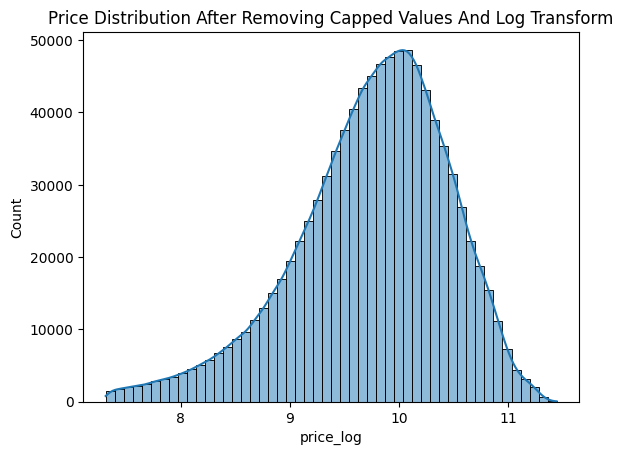

In [30]:
sns.histplot(df['price_log'], kde=True, bins=50)
plt.title('Price Distribution After Removing Capped Values And Log Transform')
plt.show()

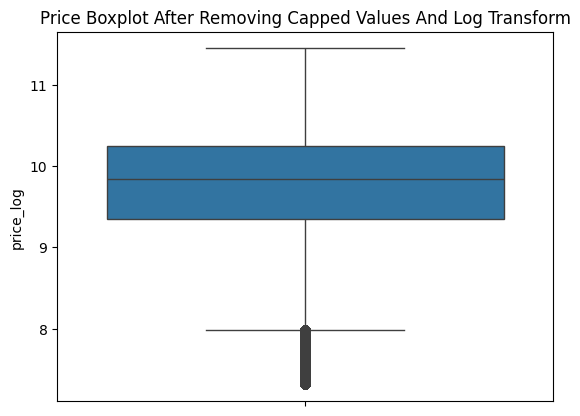

In [31]:
sns.boxplot(df['price_log'])
plt.title('Price Boxplot After Removing Capped Values And Log Transform')
plt.show()

- Filter Mileage

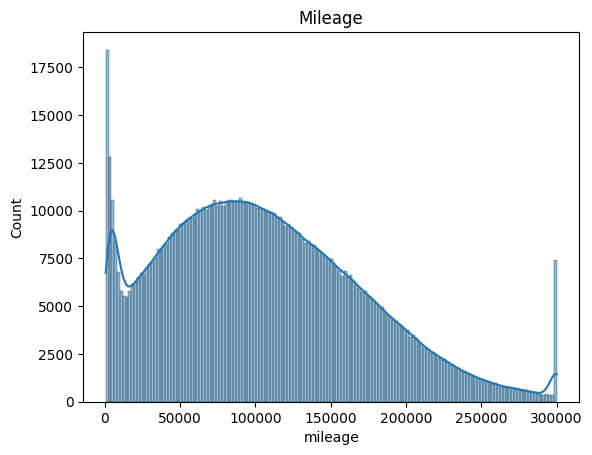

In [32]:
sns.histplot(df['mileage'], kde=True)
plt.title('Mileage')
plt.show()

In [33]:
print(df[df['mileage'] < 1000].shape[0])

7892


In [34]:
print(f"mileage=300000: {(df['mileage']==300000).sum()}")

df_clean = df[(df['mileage'] < 300000)]

print(f"Original shape: {df.shape}")
print(f"Shape after cleaning mileage: {df_clean.shape}")
print(f"Total rows dropped: {df.shape[0] - df_clean.shape[0]}")

mileage=300000: 7061
Original shape: (953016, 12)
Shape after cleaning mileage: (945955, 12)
Total rows dropped: 7061


In [35]:
df.columns

Index(['make', 'model', 'year', 'mileage', 'transmission', 'fuel_type',
       'drivetrain', 'body_type', 'trim', 'price', 'engine_capacity',
       'price_log'],
      dtype='object')

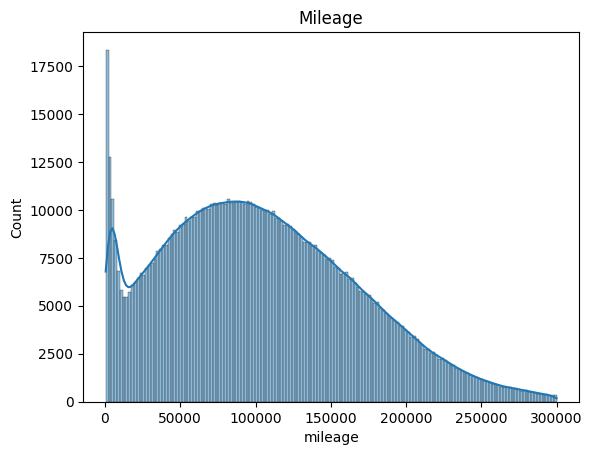

In [36]:
sns.histplot(df_clean['mileage'], kde=True)
plt.title('Mileage')
plt.show()

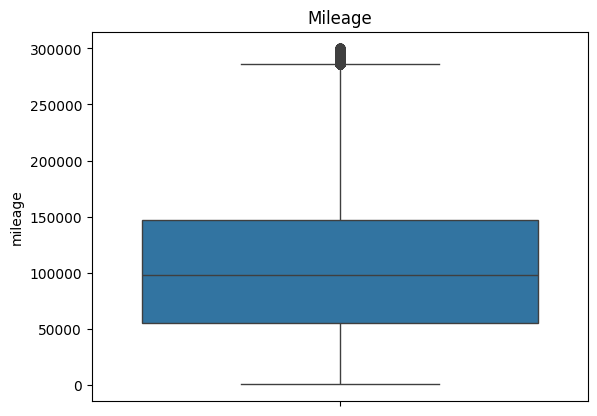

In [37]:
sns.boxplot(df_clean['mileage'])
plt.title('Mileage')
plt.show()

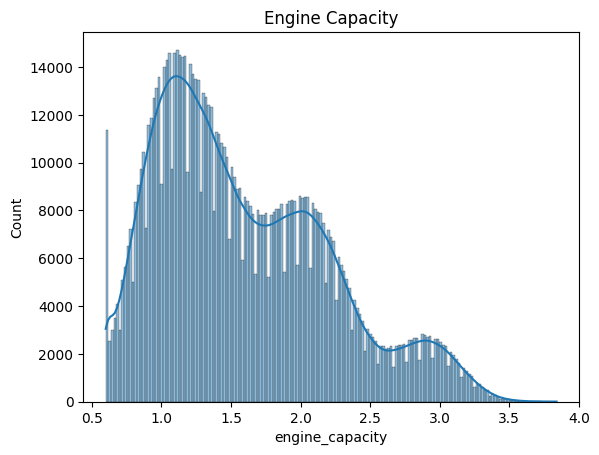

In [38]:
sns.histplot(df_clean['engine_capacity'], kde=True)
plt.title('Engine Capacity')
plt.show()

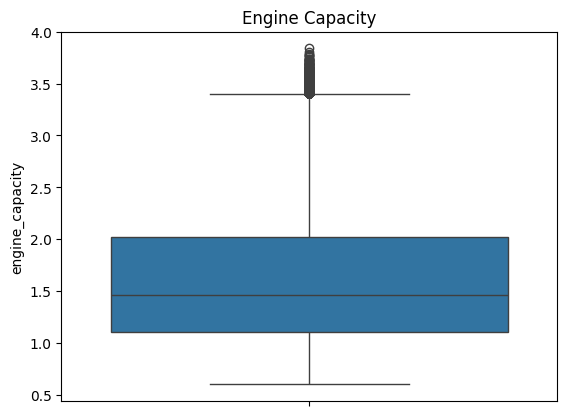

In [39]:
sns.boxplot(df_clean['engine_capacity'])
plt.title('Engine Capacity')
plt.show()

* -- BiVariate

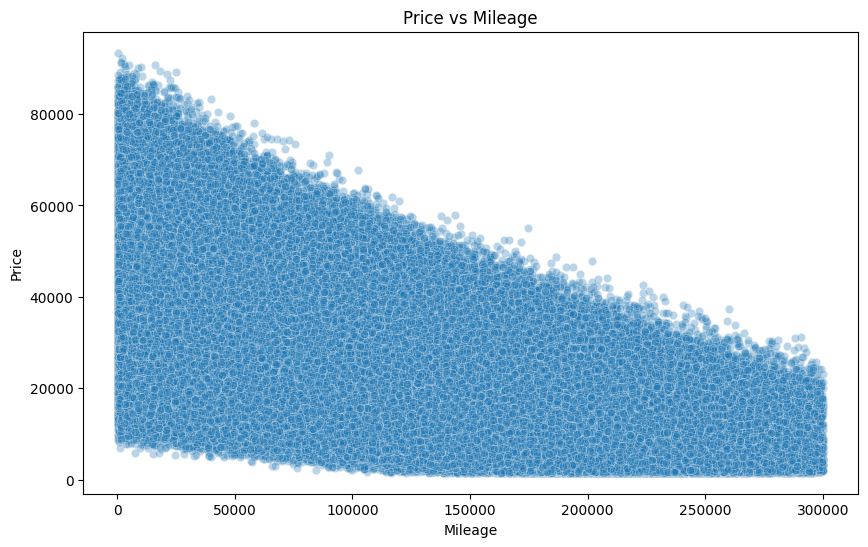

In [40]:
# Price vs Mileage (scatter)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='mileage', y='price', alpha=0.3)
plt.title("Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

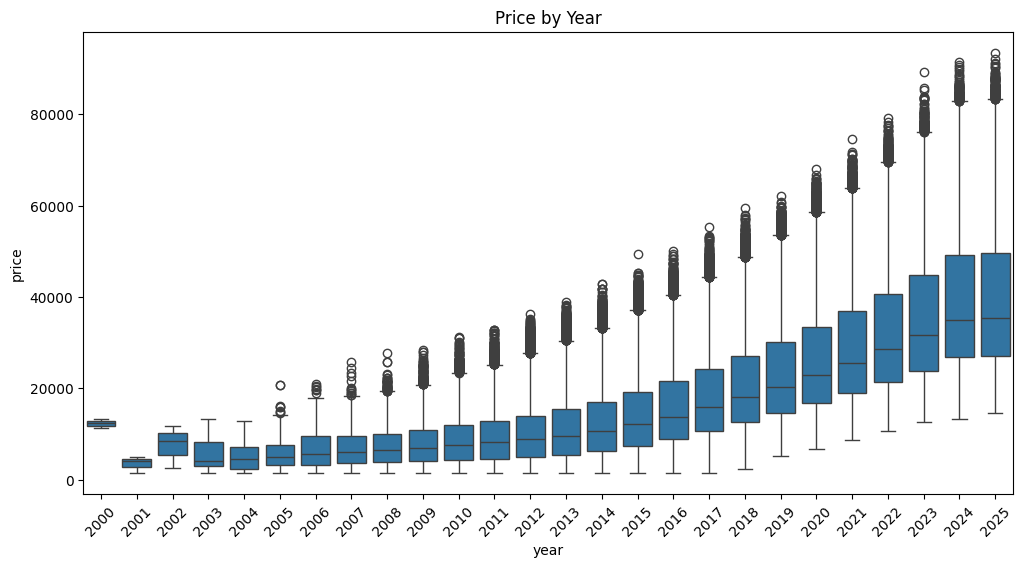

In [41]:
#  Price vs Year
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='year', y='price')
plt.title("Price by Year")
plt.xticks(rotation=45)
plt.show()

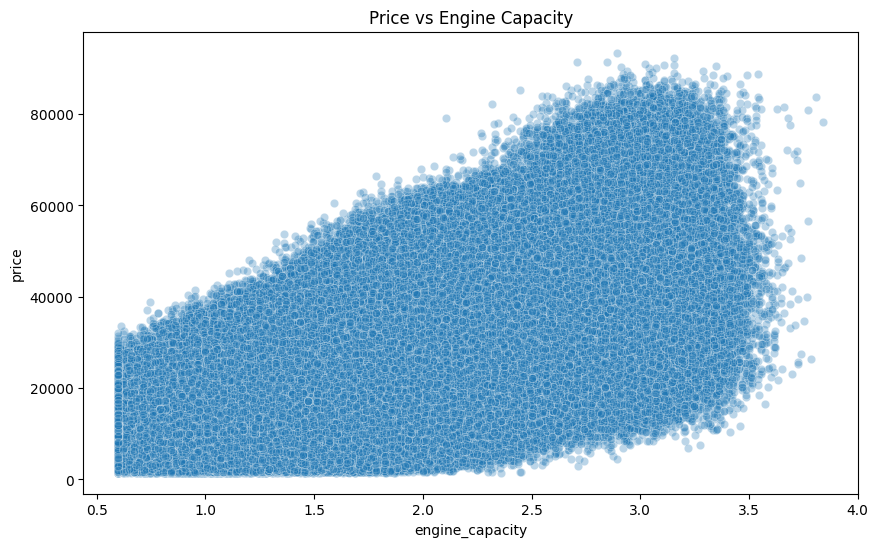

In [42]:
# Price vs Engine Capacity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='engine_capacity', y='price', alpha=0.3)
plt.title("Price vs Engine Capacity")
plt.show()

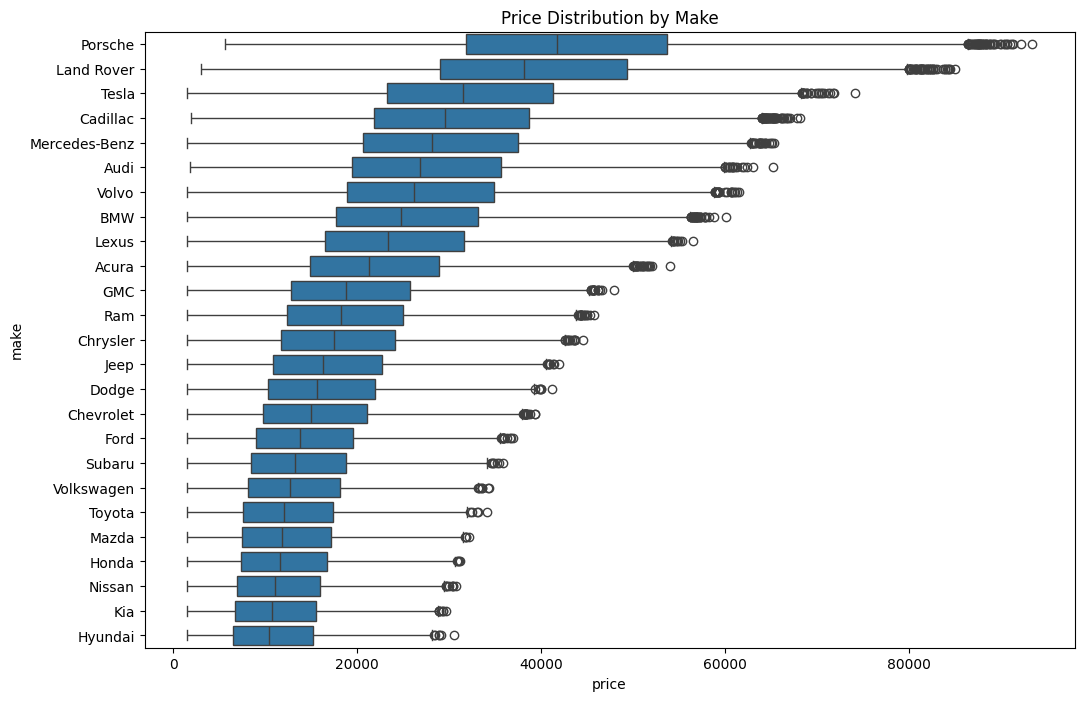

In [43]:
# Price by Make
plt.figure(figsize=(12, 8))
order = df_clean.groupby('make')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, y='make', x='price', order=order)
plt.title("Price Distribution by Make")
plt.show()

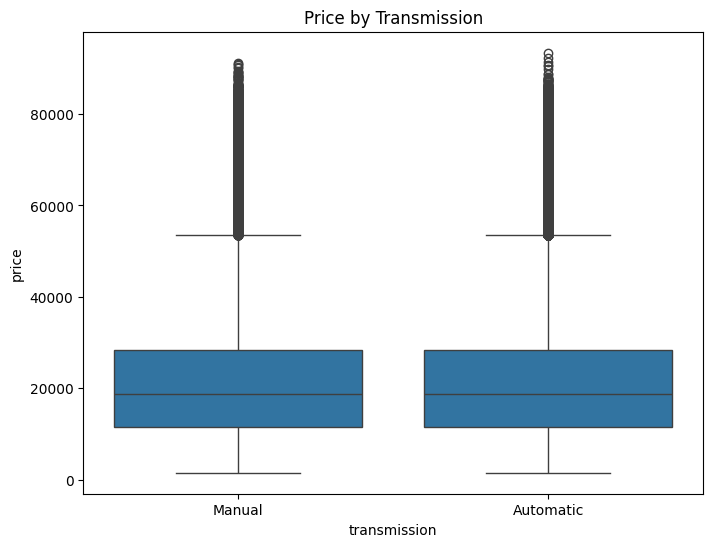

In [44]:
# Price by Transmission
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='transmission', y='price')
plt.title("Price by Transmission")
plt.show()

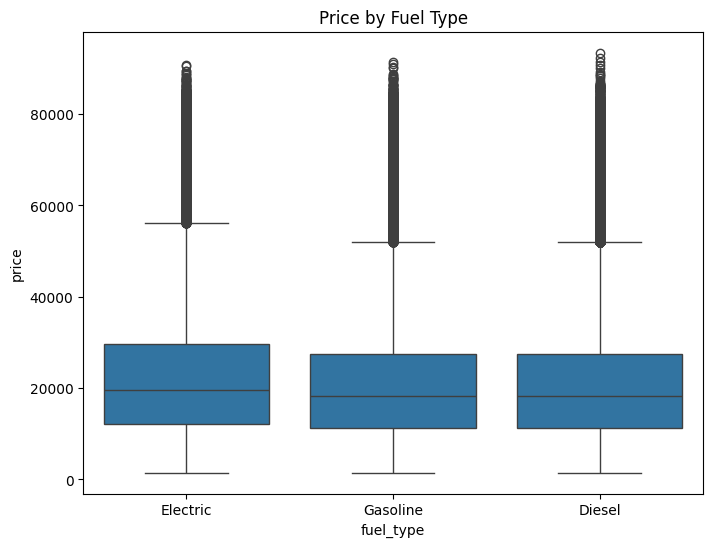

In [45]:
# Price by Fuel Type
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='fuel_type', y='price')
plt.title("Price by Fuel Type")
plt.show()

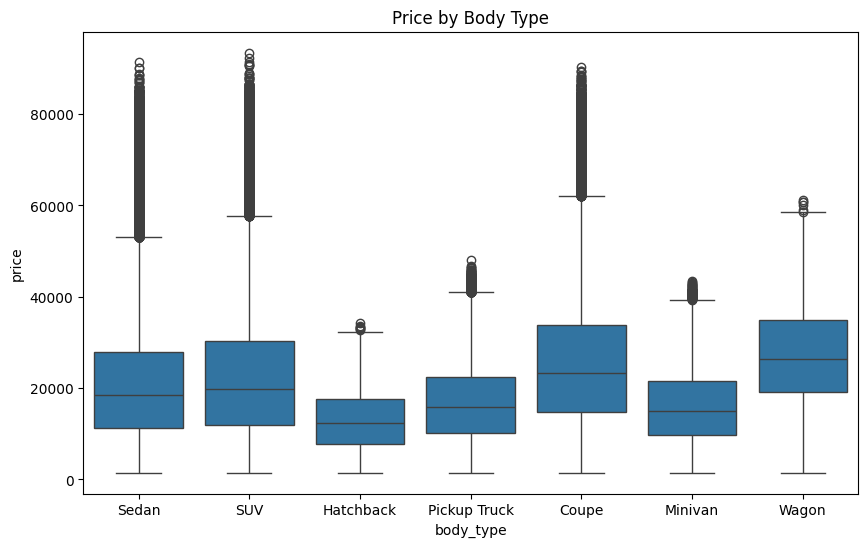

In [46]:
#  Price by Body Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='body_type', y='price')
plt.title("Price by Body Type")
plt.show()

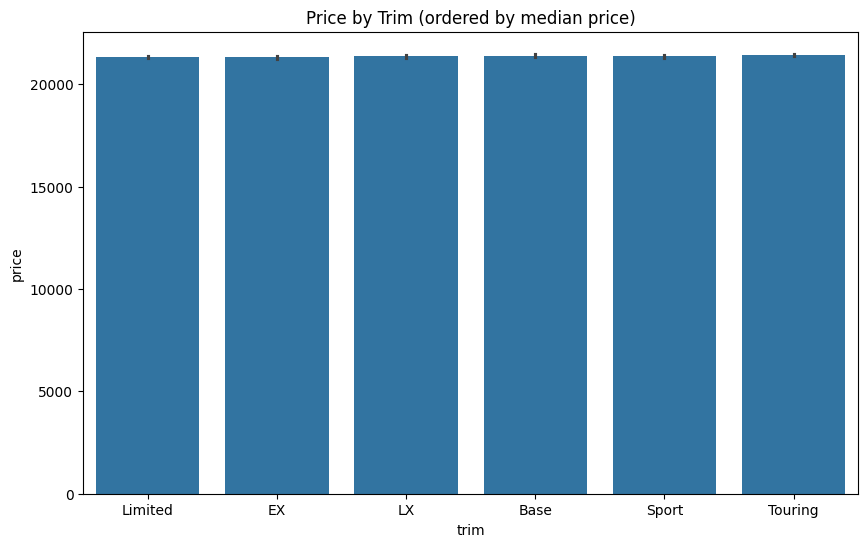

In [47]:
# Price by Trim
plt.figure(figsize=(10, 6))
order = df_clean.groupby('trim')['price'].median().sort_values().index
sns.barplot(data=df_clean, x='trim', y='price', order=order)
plt.title("Price by Trim (ordered by median price)")
plt.show()

* MultiVariate

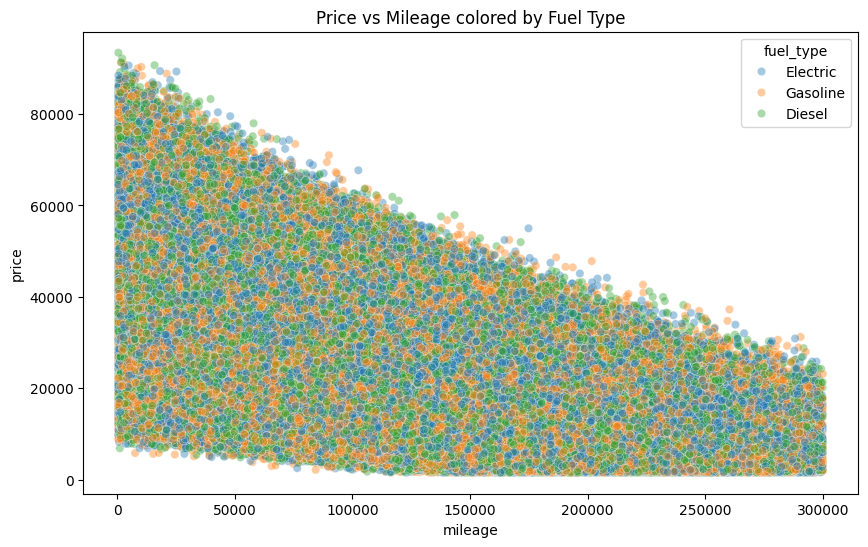

In [48]:
#  Mileage vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='mileage', y='price', hue='fuel_type', alpha=0.4)
plt.title("Price vs Mileage colored by Fuel Type")
plt.show()

* Split To Train & Test

In [49]:
# To Features And Target
X = df_clean.drop(columns=['price','price_log'], axis=1)
y = df_clean['price_log']

# To Train And Test
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=.3 ,shuffle=True, random_state=45)


# Check Shapes
print('X_train.shape \t', X_train.shape)
print('X_test.shape \t', X_test.shape)
print('***'*10)
print('y_train.shape \t', y_train.shape)
print('y_test.shape \t', y_test.shape)


X_train.shape 	 (662168, 10)
X_test.shape 	 (283787, 10)
******************************
y_train.shape 	 (662168,)
y_test.shape 	 (283787,)


In [50]:
df_clean.columns

Index(['make', 'model', 'year', 'mileage', 'transmission', 'fuel_type',
       'drivetrain', 'body_type', 'trim', 'price', 'engine_capacity',
       'price_log'],
      dtype='object')

* Feature Selectin & Preprocessing

In [51]:
# Slice Cols
num_cols = ['year', 'mileage', 'engine_capacity']

categ_ordinal_cols = ['trim']

categ_label_cols = ['make', 'model']

categ_nominal_cols = ['transmission', 'fuel_type', 'drivetrain', 'body_type']

* Pipeline

In [52]:
# Pipeline

num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categ_ordinal_pipeline = Pipeline([
    ('ord', OrdinalEncoder(categories=[['Base', 'LX', 'EX', 'Sport', 'Touring', 'Limited']]))
])

categ_label_pipeline = Pipeline([
    ('label', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

categ_nominal_pipeline = Pipeline([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numerical', num_pipeline, num_cols),
    ('categorical_ordinal', categ_ordinal_pipeline, categ_ordinal_cols),
    ('categorical_label', categ_label_pipeline, categ_label_cols),
    ('categorical_nominal', categ_nominal_pipeline, categ_nominal_cols)
])

X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

print(X_train_final.shape)

(662168, 17)


In [53]:
X_train_final = X_train_final.astype('float32')
X_test_final = X_test_final.astype('float32')

In [54]:
# Check Train
X_train_final.shape, y_train.shape



((662168, 17), (662168,))

In [55]:
# Check Test
X_test_final.shape, y_test.shape



((283787, 17), (283787,))

In [56]:
# Create Folder For The Models
MODELS_FOLDER_PATH = os.path.join(os.getcwd(), '..', 'models')
os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)

In [57]:
# Dump The Preprocessor
joblib.dump(preprocessor, os.path.join(MODELS_FOLDER_PATH, 'preprocessor.pkl'))

['c:\\Users\\eyad0\\Documents\\python\\Agoor\\Cars_Prediction\\notebook\\..\\models\\preprocessor.pkl']

In [58]:
X_train.columns

Index(['make', 'model', 'year', 'mileage', 'transmission', 'fuel_type',
       'drivetrain', 'body_type', 'trim', 'engine_capacity'],
      dtype='object')

In [59]:
print(df_clean['make'].unique())
print(df_clean['model'].unique())
print(df_clean['transmission'].unique())
print(df_clean['fuel_type'].unique())
print(df_clean['drivetrain'].unique())
print(df_clean['body_type'].unique())
print(df_clean['trim'].unique())

['Volkswagen' 'Lexus' 'Subaru' 'Cadillac' 'Toyota' 'Land Rover' 'Mazda'
 'Ram' 'Chrysler' 'GMC' 'Volvo' 'Audi' 'Chevrolet' 'Tesla' 'Hyundai'
 'Ford' 'Porsche' 'Acura' 'Nissan' 'Kia' 'Jeep' 'BMW' 'Dodge'
 'Mercedes-Benz' 'Honda']
['Jetta' 'RX' 'Crosstrek' 'Lyriq' 'Highlander' 'Defender' 'Mazda3' 'Atlas'
 '2500' '300' 'Yukon' 'XT5' 'Range Rover' 'S60' 'Camry' 'Q5' 'Silverado'
 'Model 3' '3500' 'Sonata' 'Camaro' 'Explorer' '911' 'MDX' 'Sentra'
 'Mustang' 'Discovery' 'R8' 'Forte' 'Equinox' 'Model Y' '1500'
 'Grand Cherokee' 'Mazda6' 'M3' 'Malibu' 'Pacifica' 'Panamera'
 'Pathfinder' 'V60' 'A6' 'Sorento' 'Cherokee' 'IS' 'Macan' '3 Series'
 'Durango' 'Titan' 'Tiguan' 'TLX' 'S-Class' 'E-Class' 'Tucson' 'RDX'
 'Corolla' 'RAV4' 'F-150' 'X5' 'Outback' 'Cayenne' 'Rogue' 'Accord'
 'Acadia' 'ES' 'Sportage' 'Tacoma' 'CT5' 'Sierra' 'Wrangler' 'Altima'
 'Model S' 'GLE' 'NX' 'Tahoe' 'Q7' 'Integra' 'Impreza' 'Terrain' 'Civic'
 'XC60' 'X3' 'Golf' 'Escape' 'XC90' 'CX-9' 'Focus' 'CX-5' 'Odyssey'
 'Elantra' 

In [60]:
print(df[['year', 'mileage', 'engine_capacity']].describe())

                year        mileage  engine_capacity
count  953016.000000  953016.000000    953016.000000
mean     2017.774094  105606.452227         1.596832
std         3.676353   65726.959560         0.625187
min      2000.000000     500.000000         0.600000
25%      2015.000000   55364.000000         1.100000
50%      2018.000000   99000.000000         1.467000
75%      2020.000000  148621.000000         2.027000
max      2025.000000  300000.000000         3.873000


* Building Models

--- Let's Consider The Evaluation Metric To Be RMSE, MAE, r2_score

In [70]:
# 1. Using LinerRegression (Base)
lin_base = LinearRegression(n_jobs=-1)
lin_base.fit(X_train_final,y_train)


y_pred_train_lin_base = lin_base.predict(X_train_final)
y_pred_test_lin_base = lin_base.predict(X_test_final)

# RMSE
score_train_lin_base_rmse = root_mean_squared_error(y_train,y_pred_train_lin_base)
score_test_lin_base_rmse = root_mean_squared_error(y_test,y_pred_test_lin_base)


# MAE
score_train_lin_base_mae = mean_absolute_error(y_train,y_pred_train_lin_base)
score_test_lin_base_mae = mean_absolute_error(y_test,y_pred_test_lin_base)


# R2_Score
score_train_lin_base_r2 = r2_score(y_train,y_pred_train_lin_base)
score_test_lin_base_r2 = r2_score(y_test,y_pred_test_lin_base)


print(f"The RMSE using linear regression base for trainig : {score_train_lin_base_rmse}")
print(f"The RMSE using linear regression base for testing : {score_test_lin_base_rmse}")
print('*'*50)
print(f"The Mae using linear regression base for trainig : {score_train_lin_base_mae}")
print(f"The Mae using linear regression base for testing : {score_test_lin_base_mae}")
print('*'*50)
print(f"The r2 using linear regression base for trainig : {score_train_lin_base_r2}")
print(f"The r2 using linear regression base for testing : {score_test_lin_base_r2}")

The RMSE using linear regression base for trainig : 0.7005131876724593
The RMSE using linear regression base for testing : 0.7001813670699852
**************************************************
The Mae using linear regression base for trainig : 0.5507665167564479
The Mae using linear regression base for testing : 0.5502269521673276
**************************************************
The r2 using linear regression base for trainig : 0.0009199779184840828
The r2 using linear regression base for testing : 0.0009189211987078449


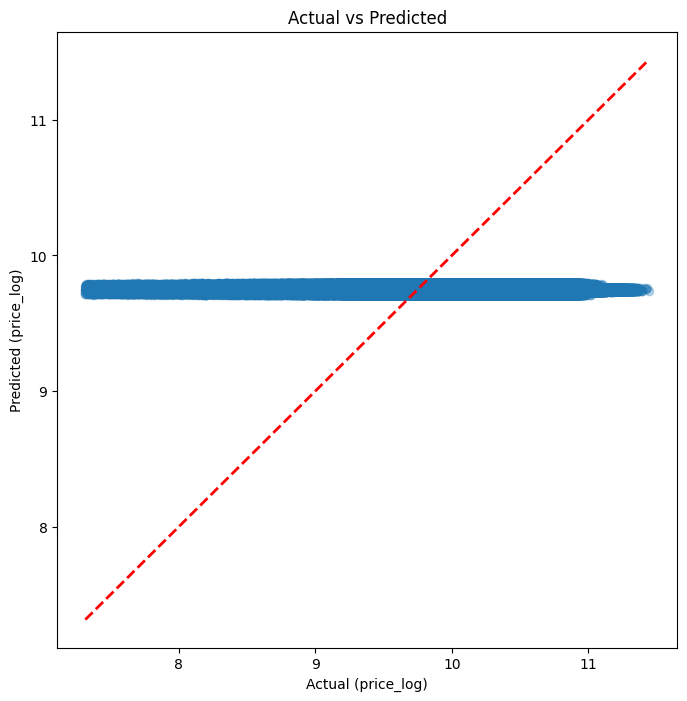

In [71]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test_lin_base, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual (price_log)")
plt.ylabel("Predicted (price_log)")
plt.title("Actual vs Predicted")
plt.show()

- Predictions follow the diagonal in the mid-range but drift away at both extremes:
- overpredicting cheap cars and underpredicting expensive ones — sign of non-linearity.

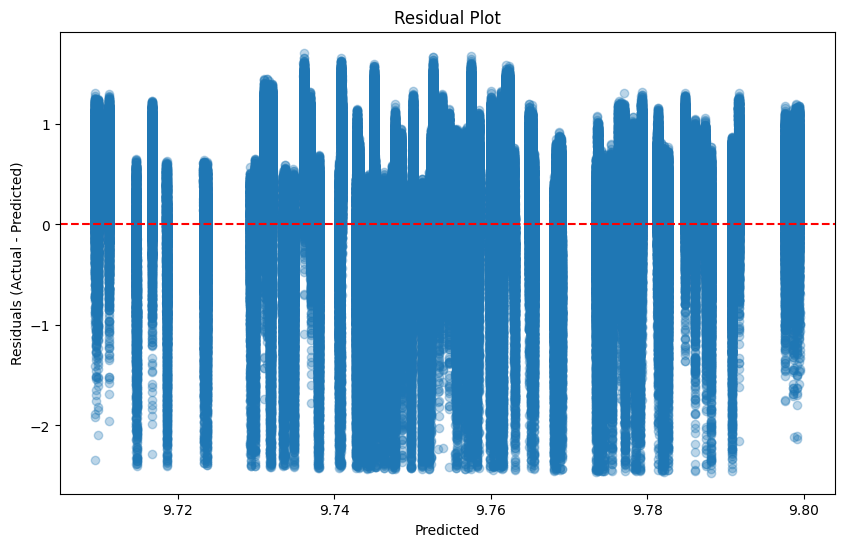

In [72]:
residuals = y_test - y_pred_test_lin_base

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_lin_base, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

- Residuals form a curved (non-random) pattern instead of scattering around zero,
- meaning Linear Regression is missing a non-linear relationship in the data.

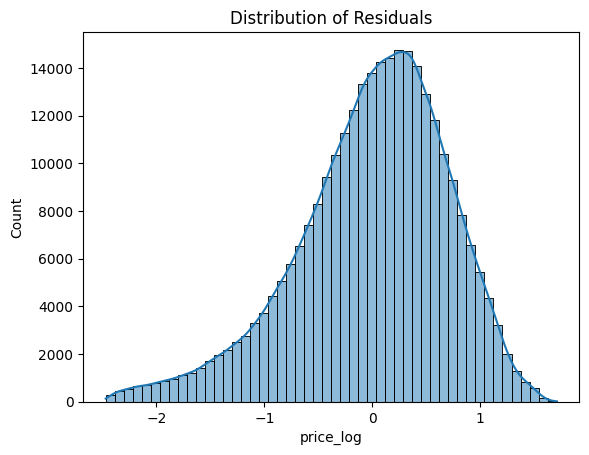

In [73]:
sns.histplot(residuals, kde=True, bins=50)
plt.title("Distribution of Residuals")
plt.show()

- Residuals are centered near zero but skewed with a long negative tail,
- confirming a systematic bias rather than pure random error.

* Random Forest

In [80]:
# Using Base RF
forest_base = RandomForestRegressor(n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=45,
    n_jobs=-1)

forest_base.fit(X_train_final, y_train)

# Predict And Evaluate
y_pred_train_forest_base = forest_base.predict(X_train_final)
y_pred_test_forest_base = forest_base.predict(X_test_final)

score_train_forest_base_rmse = root_mean_squared_error(y_train,y_pred_train_forest_base)
score_test_forest_base_rmse = root_mean_squared_error(y_test,y_pred_test_forest_base)


# MAE
score_train_forest_base_mae = mean_absolute_error(y_train,y_pred_train_forest_base)
score_test_forest_base_mae = mean_absolute_error(y_test,y_pred_test_forest_base)


# R2_Score
score_train_forest_base_r2 = r2_score(y_train,y_pred_train_forest_base)
score_test_forest_base_r2 = r2_score(y_test,y_pred_test_forest_base)


print(f"The RMSE using Random Forest regression base for trainig : {score_train_forest_base_rmse}")
print(f"The RMSE using Random Forest regression base for testing : {score_test_forest_base_rmse}")
print('*'*50)
print(f"The Mae using Random Forest regression base for trainig : {score_train_forest_base_mae}")
print(f"The Mae using Random Forest regression base for testing : {score_test_forest_base_mae}")
print('*'*50)
print(f"The r2 using Random Forest regression base for trainig : {score_train_forest_base_r2}")
print(f"The r2 using Random Forest regression base for testing : {score_test_forest_base_r2}")

The RMSE using Random Forest regression base for trainig : 0.08864697122077077
The RMSE using Random Forest regression base for testing : 0.11599209222438021
**************************************************
The Mae using Random Forest regression base for trainig : 0.06693085878324478
The Mae using Random Forest regression base for testing : 0.08716131407287273
**************************************************
The r2 using Random Forest regression base for trainig : 0.9840009038990198
The r2 using Random Forest regression base for testing : 0.9725819603723834


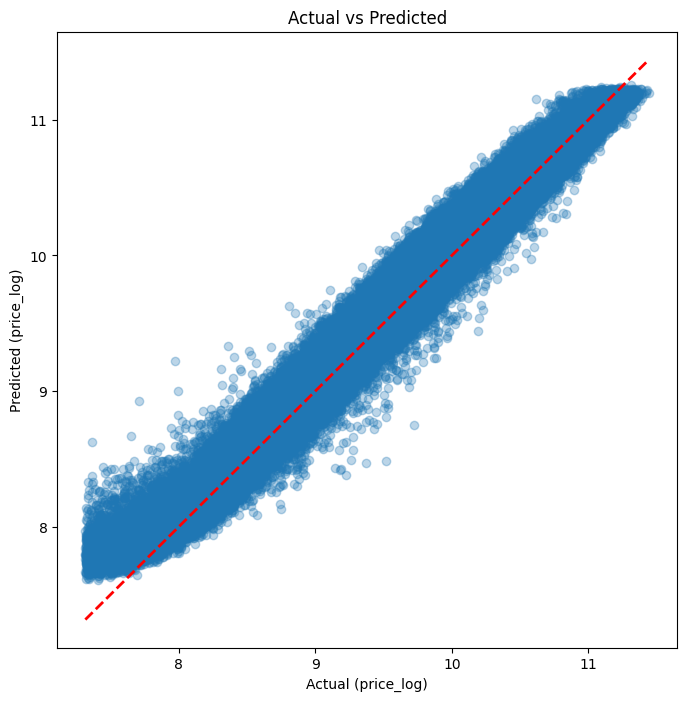

In [81]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test_forest_base, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual (price_log)")
plt.ylabel("Predicted (price_log)")
plt.title("Actual vs Predicted")
plt.show()

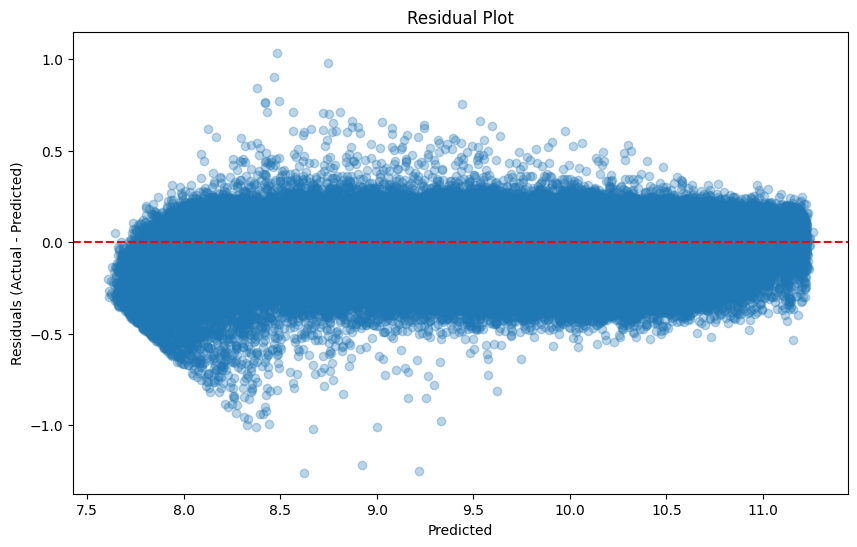

In [82]:
residuals = y_test - y_pred_test_forest_base

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_forest_base, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

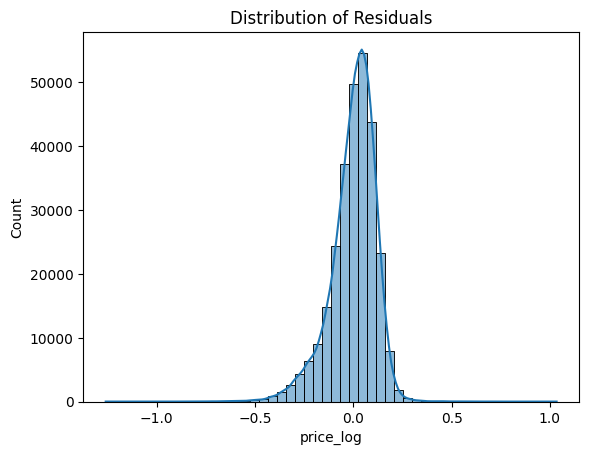

In [83]:
sns.histplot(residuals, kde=True, bins=50)
plt.title("Distribution of Residuals")
plt.show()

In [85]:
# Dump Base RF Model
joblib.dump(forest_base, os.path.join(MODELS_FOLDER_PATH, 'forest_base.pkl'))   

['c:\\Users\\eyad0\\Documents\\python\\Agoor\\Cars_Prediction\\notebook\\..\\models\\forest_base.pkl']

In [61]:
model_path = os.path.join(os.getcwd(), MODELS_FOLDER_PATH, 'forest_base.pkl')
forest = joblib.load(model_path)

In [64]:
# Get The Features Out From The Preprocessor
features_after = [name.split('__')[1] for name in preprocessor.get_feature_names_out()]
features_after

['year',
 'mileage',
 'engine_capacity',
 'trim',
 'make',
 'model',
 'transmission_Manual',
 'fuel_type_Electric',
 'fuel_type_Gasoline',
 'drivetrain_FWD',
 'drivetrain_RWD',
 'body_type_Hatchback',
 'body_type_Minivan',
 'body_type_Pickup Truck',
 'body_type_SUV',
 'body_type_Sedan',
 'body_type_Wagon']

* RF - Tunning

In [66]:
forest_importance =  pd.DataFrame({'feature': features_after,
                                         'importance': forest.feature_importances_}).sort_values('importance', ascending=False)

forest_importance

,feature,importance
2,engine_capacity,0.331755
0,year,0.318757
1,mileage,0.224950
4,make,0.077361
5,model,0.027858
13,body_type_Pickup Truck,0.004912
11,body_type_Hatchback,0.003490
3,trim,0.002276
14,body_type_SUV,0.001455
15,body_type_Sedan,0.001306


* RF-Tunning

In [ ]:
params_narrow = {
    'n_estimators': [150, 200, 250],
    'max_depth': [15, 20, 25],
    'min_samples_split': [3, 5, 8],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt']
}

random_search_forest_narrow = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=45, n_jobs=-1),
    param_distributions=params_narrow,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='neg_root_mean_squared_error',
    n_iter=15,
    random_state=45
)
random_search_forest_narrow.fit(X_train_final, y_train)

In [ ]:
# The Best Score According To Your Scoring & The Best Combination Of What You Search In
random_search_forest_narrow.best_score_, random_search_forest_narrow.best_params_

* Tuned Params

In [ ]:
forest_tuned = RandomForestRegressor(
    n_estimators=250,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=25,
    random_state=45,
    n_jobs=-1
)

forest_tuned.fit(X_train_final, y_train)

## Due To LOW RESOURCES Can't Tunning, So Use Base RF

In [ ]:
# Predict And Evaluate
y_pred_train_forest_tuned = forest_tuned.predict(X_train_final)
y_pred_test_forest_tuned = forest_tuned.predict(X_test_final)

score_train_forest_tuned_rmse = root_mean_squared_error(y_train,y_pred_train_forest_tuned)
score_test_forest_tuned_rmse = root_mean_squared_error(y_test,y_pred_test_forest_tuned)


# MAE
score_train_forest_tuned_mae = mean_absolute_error(y_train,y_pred_train_forest_tuned)
score_test_forest_tuned_mae = mean_absolute_error(y_test,y_pred_test_forest_tuned)


# R2_Score
score_train_forest_tuned_r2 = r2_score(y_train,y_pred_train_forest_tuned)
score_test_forest_tuned_r2 = r2_score(y_test,y_pred_test_forest_tuned)


print(f"The RMSE using Random Forest regression Tuned Using Random Search for trainig : {score_train_forest_tuned_rmse}")
print(f"The RMSE using Random Forest regression Tuned Using Random Search for testing : {score_test_forest_tuned_rmse}")
print('*'*50)
print(f"The Mae using Random Forest regression Tuned Using Random Search for trainig : {score_train_forest_tuned_mae}")
print(f"The Mae using Random Forest regression Tuned Using Random Search for testing : {score_test_forest_tuned_mae}")
print('*'*50)
print(f"The r2 using Random Forest regression Tuned Using Random Search for trainig : {score_train_forest_tuned_r2}")
print(f"The r2 using Random Forest regression Tuned Using Random Search for testing : {score_test_forest_tuned_r2}")

In [ ]:
# The RMSE using Random Forest regression Tuned Using Random Search for trainig : 0.056517675119748846
# The RMSE using Random Forest regression Tuned Using Random Search for testing : 0.11344981890116876
# **************************************************
# The Mae using Random Forest regression Tuned Using Random Search for trainig : 0.04298865874294871
# The Mae using Random Forest regression Tuned Using Random Search for testing : 0.08586069945161892
# **************************************************
# The r2 using Random Forest regression Tuned Using Random Search for trainig : 0.9934966635795097
# The r2 using Random Forest regression Tuned Using Random Search for testing : 0.9737706668442798

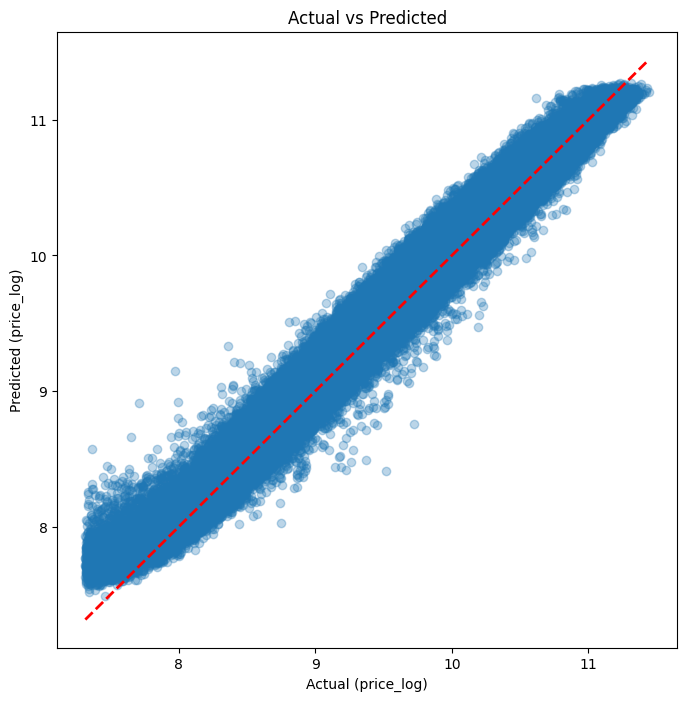

In [73]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test_forest_tuned, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual (price_log)")
plt.ylabel("Predicted (price_log)")
plt.title("Actual vs Predicted")
plt.show()

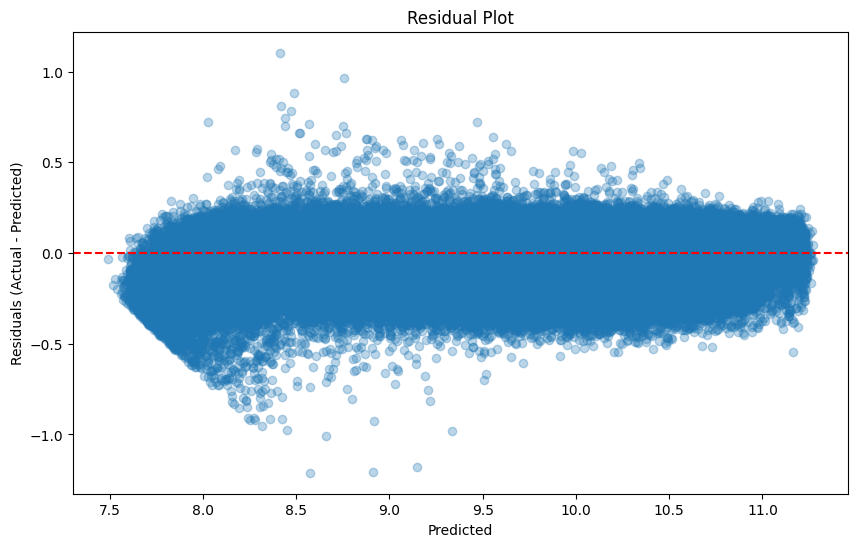

In [74]:
residuals = y_test - y_pred_test_forest_tuned

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_forest_tuned, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

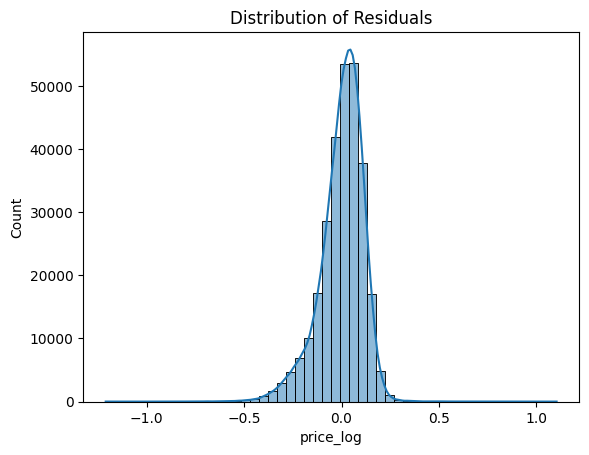

In [75]:
sns.histplot(residuals, kde=True, bins=50)
plt.title("Distribution of Residuals")
plt.show()

In [ ]:
# Dump Models
joblib.dump(forest_tuned, os.path.join(MODELS_FOLDER_PATH, 'forest_tuned.pkl'))   